In [1]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!wget -q https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
!unzip -q cell_images.zip

In [3]:
!ls


cell_images  cell_images.zip  sample_data


In [4]:
!ls cell_images

Parasitized  Uninfected


In [5]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

print("Classes:", train_ds.class_names)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Classes: ['Parasitized', 'Uninfected']


In [6]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 54s 67ms/step - accuracy: 0.8446 - loss: 0.3919 - val_accuracy: 0.9350 - val_loss: 0.2129
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 68s 57ms/step - accuracy: 0.9348 - loss: 0.1970 - val_accuracy: 0.9394 - val_loss: 0.1810
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 48s 66ms/step - accuracy: 0.9437 - loss: 0.1597 - val_accuracy: 0.9472 - val_loss: 0.1481
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.9526 - loss: 0.1401 - val_accuracy: 0.9525 - val_loss: 0.1642
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9566 - loss: 0.1290 - val_accuracy: 0.9503 - val_loss: 0.1538


In [8]:
model.evaluate(val_ds)

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9503 - loss: 0.1538


[0.1537615805864334, 0.9502812623977661]

In [9]:

model.save('/content/malaria_model.h5')

In [10]:
!ls


cell_images  cell_images.zip  malaria_model.h5	sample_data


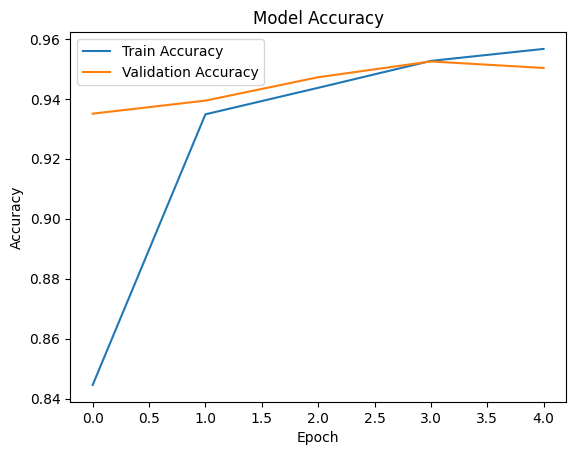

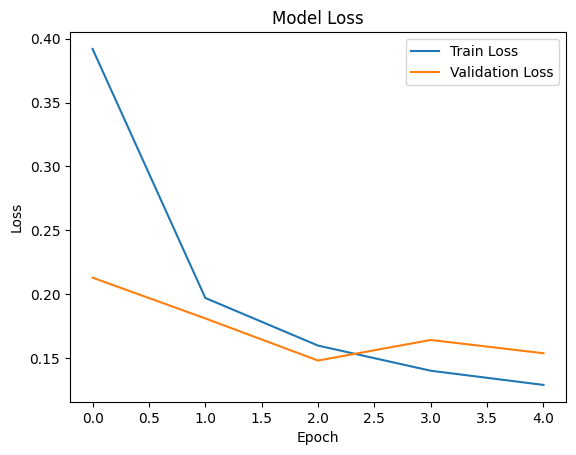

In [11]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step
🦠 Parasitized (Malaria Infected)


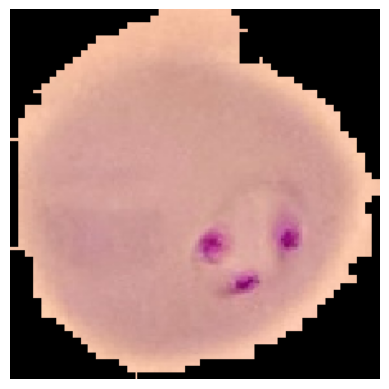

In [12]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

model = load_model("malaria_model.h5")

img_path = "cell_images/Parasitized/C33P1thinF_IMG_20150619_114756a_cell_179.png"

img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis("off")

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("🦠 Parasitized (Malaria Infected)")
else:
    print("✅ Uninfected (Healthy)")

In [28]:
%%writefile app.py
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

st.title("🦠 Malaria Detection using Deep Learning")

@st.cache_resource
def load_ml_model():
    return load_model("malaria_model.h5")

model = load_ml_model()

uploaded_file = st.file_uploader("Upload Cell Image", type=["jpg","png","jpeg"])

if uploaded_file is not None:

    img = Image.open(uploaded_file).convert("RGB").resize((224,224))
    st.image(img, caption="Uploaded Image", width=300)

    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    score = prediction[0][0]

    st.write("Prediction Score:", score)

    if score < 0.5:
        st.error("🦠 Parasitized (Malaria Infected)")
    else:
        st.success("✅ Uninfected (Healthy)")

Overwriting app.py


In [14]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 126.3 MB/s eta 0:00:00


In [29]:
!streamlit run app.py --server.port 8501 > logs.txt 2>&1 &

In [30]:
from pyngrok import ngrok
ngrok.set_auth_token("3AvM4n4M4tFJWehuCi99bMsH1gF_7715fRJcahWLX4NXvPz7k")

In [31]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://raye-branchiostegous-roxana.ngrok-free.dev" -> "http://localhost:8501"
